In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from scipy.spatial.distance import squareform

from statsmodels.stats.multitest import multipletests

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering

from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix, classification_report
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.preprocessing import StandardScaler, Normalizer


import xgboost as xgb
import shap


import joblib
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from contextlib import contextmanager

import importlib
import bootstrap
import distribution_estimation
import plotting

# from math import erf
# from math import lgamma

importlib.reload(bootstrap)
importlib.reload(distribution_estimation)
importlib.reload(plotting)

from bootstrap import *
from distribution_estimation import *
from plotting import *

/home/francesx/.conda/envs/emotion-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
params = {
    #'booster':'gbtree',
        #'silent':0, # 1 - info output; 0 - silent
        #'scale_pos_weight': 33, # If value > 0, helps with fast convergence in case of imbalanced class samples
        'objective': 'binary:logistic', # for binary classification
        'seed':2, # random seed
        'eval_metric': 'logloss',  # binary logloss
        'eta': 0.5, # learning rate
        'max_depth': 20,
        'min_child_weight': 0.2,
        'subsample': 0.8, 
        'colsample_bytree': 0.6,
        #'gamma': 0.418,
        #'lambda': 1.814,
        #'alpha': 3.17,
       }

In [3]:
def simulate_known_importance_classification(
    n=600,          # sample size
    d=40,           # total number of features
    s=8,            # number of true signals
    sigma=1.5,      # within-group SD (moderate, not too small)
    rho=0.20,       # common correlation among features
    class_prob=0.5, # balanced classes
    max_delta=3.0,  # strongest signal separation
    min_delta=0.8,  # weakest signal separation
    seed=123
):
    """
    Simulate a two-class classification dataset with:
    - s true signal features
    - d-s noise features
    - known descending importance order among signals
    - equal within-class covariance for both groups
    """

    rng = np.random.default_rng(seed)

    if not (s < d < n):
        raise ValueError("Require s < d < n.")

    # Balanced binary response
    y = rng.binomial(1, class_prob, size=n)

    # Descending signal strengths: delta_1 > delta_2 > ... > delta_s
    deltas = np.linspace(max_delta, min_delta, s)

    # Means for the two classes
    mu1 = np.zeros(d)
    mu0 = np.zeros(d)
    mu1[:s] = deltas / 2.0
    mu0[:s] = -deltas / 2.0

    # Equal covariance for both groups
    # Exchangeable correlation structure
    R = np.full((d, d), rho)
    np.fill_diagonal(R, 1.0)
    Sigma = (sigma ** 2) * R

    # Generate X | Y
    X = np.empty((n, d))

    idx1 = np.where(y == 1)[0]
    idx0 = np.where(y == 0)[0]

    if len(idx1) > 0:
        X[idx1] = rng.multivariate_normal(mean=mu1, cov=Sigma, size=len(idx1))
    if len(idx0) > 0:
        X[idx0] = rng.multivariate_normal(mean=mu0, cov=Sigma, size=len(idx0))

    feature_names = [f"x{j+1}" for j in range(d)]
    df = pd.DataFrame(X, columns=feature_names)
    df["y"] = y

    # Ground-truth importance table
    truth = pd.DataFrame({
        "feature": feature_names,
        "is_signal": [j < s for j in range(d)],
        "delta": list(deltas) + [0.0] * (d - s),
        "true_rank": list(range(1, s + 1)) + [None] * (d - s)
    })

    return df, truth, Sigma, mu0, mu1

In [4]:
import numpy as np
import pandas as pd

def simulate_zero_inflated_classification(
    n=600,
    d=40,
    s=8,
    sigma=1.5,
    pi_zero=0.3,
    max_delta=3.0,
    min_delta=0.8,
    seed=123
):
    rng = np.random.default_rng(seed)

    if not (s < d < n):
        raise ValueError("Require s < d < n.")

    y = rng.binomial(1, 0.5, size=n)
    deltas = np.linspace(max_delta, min_delta, s)

    X = np.zeros((n, d))

    for j in range(d):
        is_signal = j < s
        delta_j = deltas[j] if is_signal else 0.0

        mu1 = delta_j / 2.0
        mu0 = -delta_j / 2.0

        for i in range(n):
            if rng.random() < pi_zero:
                X[i, j] = 0.0
            else:
                mu = mu1 if y[i] == 1 else mu0
                X[i, j] = rng.normal(mu, sigma)

    feature_names = [f"x{j+1}" for j in range(d)]
    df = pd.DataFrame(X, columns=feature_names)
    df["y"] = y

    truth = pd.DataFrame({
        "feature": feature_names,
        "is_signal": [j < s for j in range(d)],
        "delta": list(deltas) + [0.0] * (d - s),
        "pi_zero": [pi_zero] * d,
        "true_rank": list(range(1, s + 1)) + [None] * (d - s)
    })

    return df, truth

# Low dimension

In [160]:
df, truth = simulate_zero_inflated_classification(
    n=600,
    d=40,
    s=8,
    sigma=3,
    pi_zero=0.5,
    max_delta=2.5,
    min_delta=0.8,
    seed=123
)

# print(df.head())
print(truth.head(12))

   feature  is_signal     delta  pi_zero  true_rank
0       x1       True  2.500000      0.5        1.0
1       x2       True  2.257143      0.5        2.0
2       x3       True  2.014286      0.5        3.0
3       x4       True  1.771429      0.5        4.0
4       x5       True  1.528571      0.5        5.0
5       x6       True  1.285714      0.5        6.0
6       x7       True  1.042857      0.5        7.0
7       x8       True  0.800000      0.5        8.0
8       x9      False  0.000000      0.5        NaN
9      x10      False  0.000000      0.5        NaN
10     x11      False  0.000000      0.5        NaN
11     x12      False  0.000000      0.5        NaN


In [161]:
X = df.drop(columns="y")
y = df["y"]

In [190]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

# Prepare data for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest  = xgb.DMatrix(X_test,  label=y_test,  enable_categorical=True)
# Cross-validation on training data to find optimal parameters


num_rounds = 150 # number of iterations

In [191]:
# Perform 5-fold cross-validation on training data
print("Running 5-fold cross-validation on training data...")
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=num_rounds,
    nfold=5,  # 5-fold cross-validation
    metrics='logloss',  # binary logloss
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\n" + "="*50)
print("Cross-validation results:")
print(f"Best iteration: {len(cv_results)}")
print(f"Best CV logloss: {cv_results['test-logloss-mean'].min():.4f} (+/- {cv_results['test-logloss-std'].iloc[-1]:.4f})")
print("="*50)

# Train final model on all training data with optimal number of rounds
best_num_rounds = len(cv_results)
print(f"\nTraining final model with {best_num_rounds} rounds...")
model = xgb.train(params, dtrain, num_boost_round=best_num_rounds)

# Evaluate on held-out test set
# For binary:logistic, predict() returns probabilities, convert to class labels
y_pred_proba = model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)  # Convert probabilities to 0/1

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest set accuracy: {test_accuracy:.4f}")

# Show confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["0", "1"]))

Running 5-fold cross-validation on training data...
[0]	train-logloss:0.46771+0.00571	test-logloss:0.72846+0.02413
[1]	train-logloss:0.33526+0.00180	test-logloss:0.74506+0.03946
[2]	train-logloss:0.25170+0.00326	test-logloss:0.73630+0.04833
[3]	train-logloss:0.19504+0.00381	test-logloss:0.73850+0.04899
[4]	train-logloss:0.15956+0.00443	test-logloss:0.74677+0.05490
[5]	train-logloss:0.13086+0.00275	test-logloss:0.75792+0.05742
[6]	train-logloss:0.10877+0.00364	test-logloss:0.77054+0.05067
[7]	train-logloss:0.09169+0.00309	test-logloss:0.77183+0.05129
[8]	train-logloss:0.07941+0.00210	test-logloss:0.76391+0.04920
[9]	train-logloss:0.06943+0.00226	test-logloss:0.77215+0.04785
[10]	train-logloss:0.06118+0.00159	test-logloss:0.78071+0.05485

Cross-validation results:
Best iteration: 1
Best CV logloss: 0.7285 (+/- 0.0241)

Training final model with 1 rounds...

Test set accuracy: 0.5083

Confusion Matrix:
[[32 29]
 [30 29]]

Classification Report:
              precision    recall  f1-score 

/tmp/ipykernel_2011177/161574275.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


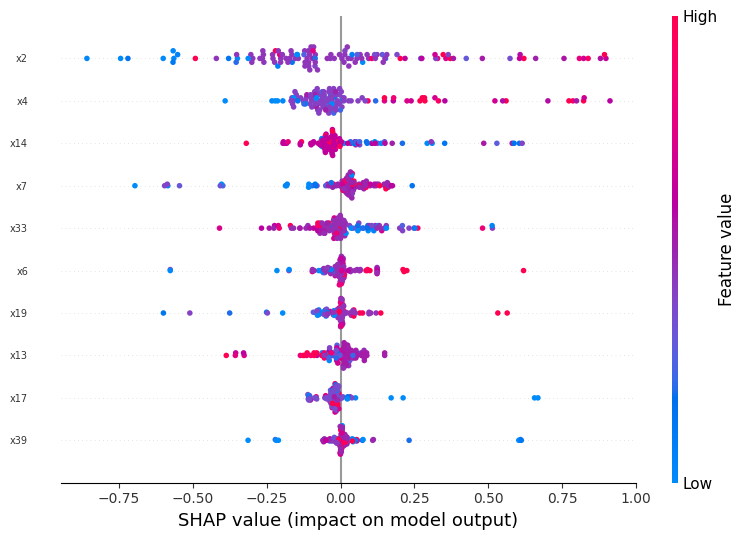

In [192]:
shap_values = model.predict(
    dtest,
    pred_contribs=True
)
plt.figure(figsize=(12, 16))
shap.summary_plot(
    shap_values[:, :-1],
    X_test,
    max_display=10,
    show=False
)

plt.yticks(fontsize=7)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

## 1000 round

In [165]:
boot_results = boot_multi_repeat_inference_keep_feature(
    X=X,
    y=y,
    task="binary",
    inner_variance="permutation",
    n_bootstrap=1000,
    b_model=1,
    zero_tol=1e-12,
    params=params,
    num_boost_round=150,
    n_jobs=6,
    xgb_nthread=1,
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [01:10<00:00, 14.28it/s]


In [166]:
feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=boot_results,
    agg_col="sum_abs_shap",
    kernel="gaussian",
    bandwidth=0.1,
)

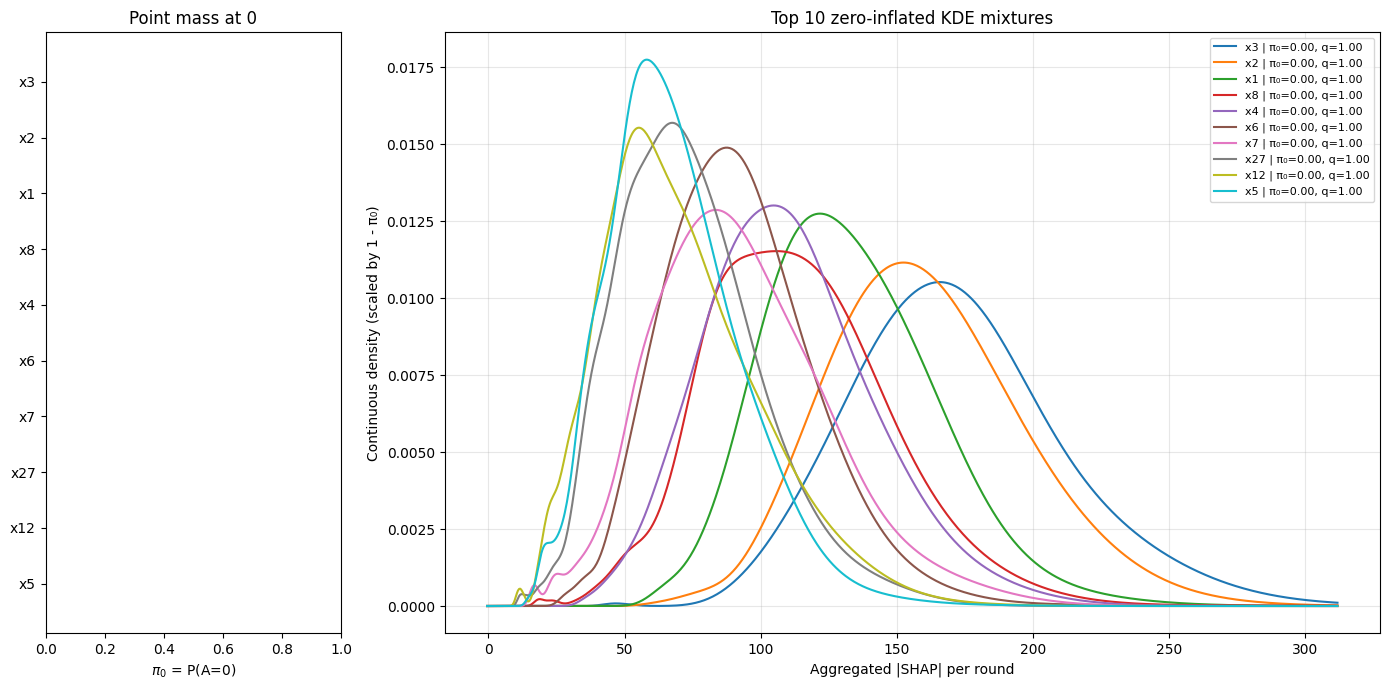

In [167]:
lgb_top = plot_top_feature_density(
    feature_kde,
    top_k=10,
    score_col="median",
    x_min = -0.5,
    log_x=False,
)

In [168]:
tmp = feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["median"] * tmp["SNR"]
                                
top = tmp.nlargest(10, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
    "feature": "ID",
    "stat": "Robust",
    "nonzero_median": "Median",
    "sd_estimated": "Std",
}).round(3)

,ID,Robust,SNR,Median,Std,0PM(%)
Rank,,,,,,
1,x3,721.234,4.237,170.231,40.179,0.0%
2,x2,680.159,4.291,158.511,36.941,0.0%
3,x1,532.249,4.077,130.543,32.018,0.0%
4,x4,376.615,3.443,109.373,31.763,0.0%
5,x8,369.815,3.293,112.292,34.097,0.0%
6,x6,298.216,3.276,91.029,27.786,0.0%
7,x7,250.952,2.787,90.043,32.308,0.0%
8,x27,193.864,2.710,71.528,26.391,0.0%
9,x5,177.530,2.686,66.100,24.611,0.0%


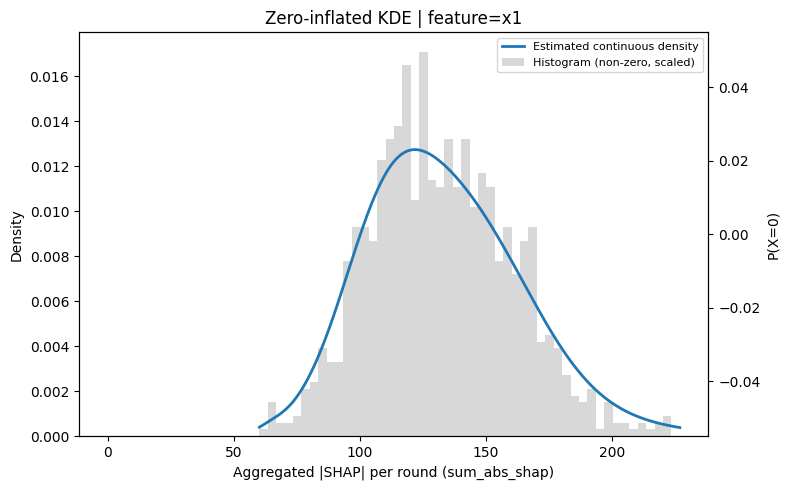

In [169]:
plot_feature_level_kde_with_hist_preagg(
    feature_level_df=feature_kde,
    boot_results=boot_results,
    feature="x1",
    bins = 50
)

In [170]:
from scipy.stats import shapiro

boot_df = pd.concat(boot_results, ignore_index=True)
x1_vals = boot_df.loc[boot_df["feature"] == "x1", "sum_abs_shap"].values

n = min(len(x1_vals), 5000)
stat, p = shapiro(x1_vals[:n])
print(f"Shapiro-Wilk normality test on x1 sum_abs_shap (n={n}):")
print(f"  W = {stat:.4f},  p = {p:.4e}")

Shapiro-Wilk normality test on x1 sum_abs_shap (n=1000):
  W = 0.9893,  p = 1.0725e-06


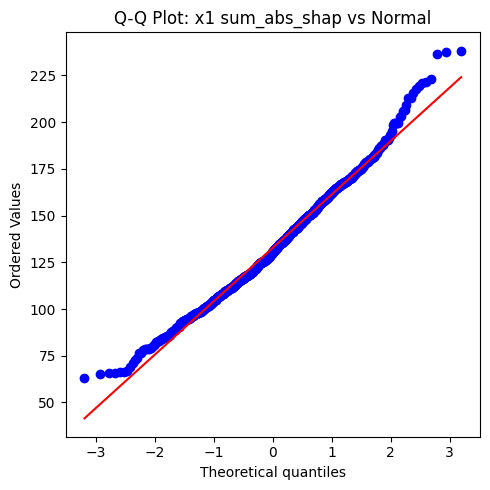

In [171]:
import scipy.stats as stats

fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(x1_vals, dist="norm", plot=ax)
ax.set_title("Q-Q Plot: x1 sum_abs_shap vs Normal")
plt.tight_layout()
plt.show()

## 10 round

In [172]:
boot_results_tiny = boot_multi_repeat_inference_keep_feature(
    X=X,
    y=y,
    task="binary",
    inner_variance="permutation",
    n_bootstrap=10,
    b_model=1,
    zero_tol=1e-12,
    params=params,
    num_boost_round=150,
    n_jobs=6,
    xgb_nthread=1,
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 10/10 [00:00<00:00, 12.20it/s]


In [173]:
feature_kde_tiny = estimate_feature_level_mixture_preagg(
    boot_results=boot_results_tiny,
    agg_col="sum_abs_shap",
    kernel="gaussian",
    bandwidth=0.2,
)

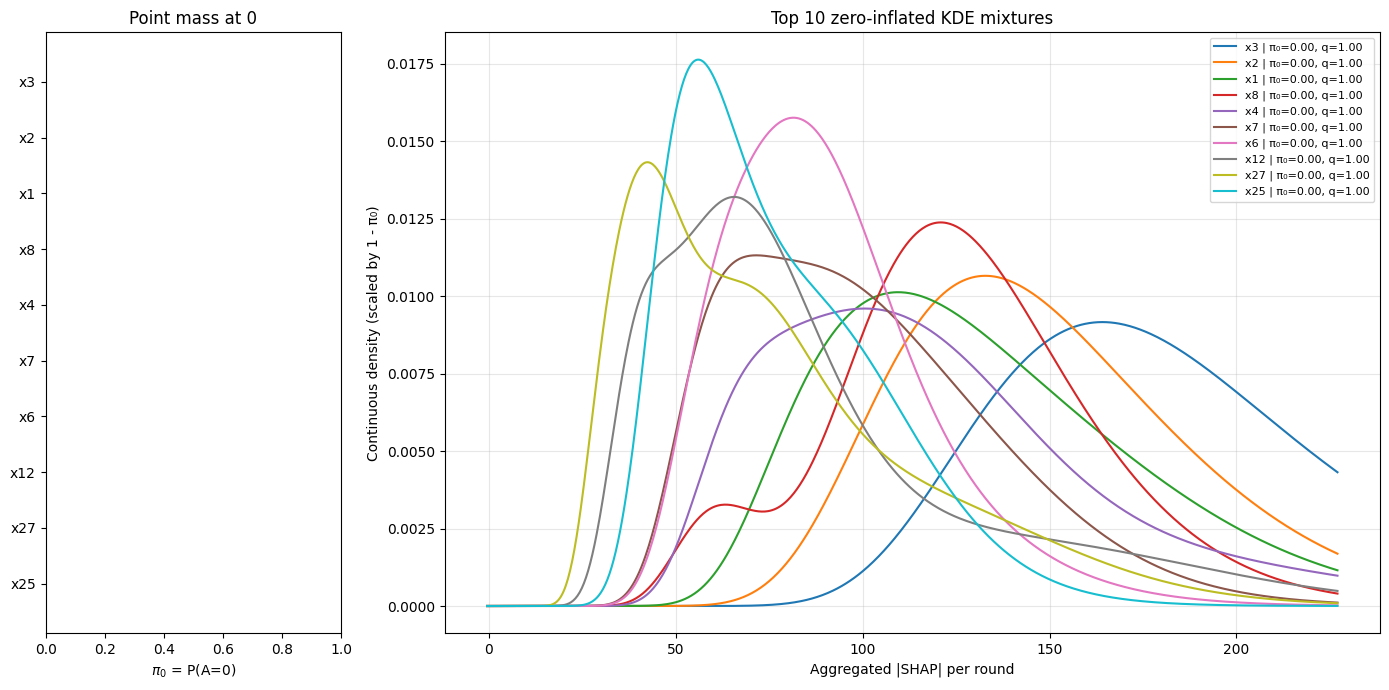

In [174]:
lgb_top = plot_top_feature_density(
    feature_kde_tiny,
    top_k=10,
    score_col="median",
    x_min = -0.5,
    log_x=False,
)

In [175]:
feature_kde_tiny.head()

,feature,n_bootstrap_rounds,n_total,n_zero,n_nonzero,pi_zero,bandwidth,kernel,zero_tol,kde_model,median,std,mean_abs_estimated,mean_estimated,var_estimated,sd_estimated,p_nonzero,peak_density,nonzero_median,nonzero_median_kde
0,x1,10,10,0,10,0.0,0.2,gaussian,0.0,"{'pi_zero': 0.0, 'n_total': 10, 'n_zero': 0, '...",122.922249,33.985439,112.213551,112.213551,2277.918870,47.727548,1.0,0.010123,122.922249,121.545113
1,x10,10,10,0,10,0.0,0.2,gaussian,0.0,"{'pi_zero': 0.0, 'n_total': 10, 'n_zero': 0, '...",43.947449,21.980774,41.480598,41.480598,457.093151,21.379737,1.0,0.026115,43.947451,41.318994
2,x11,10,10,0,10,0.0,0.2,gaussian,0.0,"{'pi_zero': 0.0, 'n_total': 10, 'n_zero': 0, '...",49.984421,23.265099,45.453432,45.453432,478.470129,21.873960,1.0,0.019883,49.984421,45.197189
3,x12,10,10,0,10,0.0,0.2,gaussian,0.0,"{'pi_zero': 0.0, 'n_total': 10, 'n_zero': 0, '...",72.149025,42.863037,75.589109,75.589109,1479.405781,38.463044,1.0,0.013196,72.149025,72.653921
4,x13,10,10,0,10,0.0,0.2,gaussian,0.0,"{'pi_zero': 0.0, 'n_total': 10, 'n_zero': 0, '...",62.940105,23.077213,50.748678,50.748678,702.211748,26.499278,1.0,0.013982,62.940105,56.935591


In [176]:
tmp = feature_kde_tiny.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["std"]
tmp["stat"] = tmp["p_nonzero"]* tmp["median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
    "feature": "ID",
    "stat": "Robust",
    "nonzero_median": "Median",
    "sd_estimated": "Std",
}).round(3)

,ID,Robust,SNR,Median,Std,0PM(%)
Rank,,,,,,
1,x3,1016.693,5.930,171.442,68.652,0.0%
2,x2,747.680,5.293,141.265,57.042,0.0%
3,x8,558.522,4.619,120.913,50.249,0.0%
4,x1,444.599,3.617,122.922,47.728,0.0%
5,x6,390.353,4.357,89.593,30.245,0.0%
6,x7,320.857,3.311,96.897,37.780,0.0%
7,x4,314.059,2.737,114.762,44.522,0.0%
8,x32,244.156,3.768,64.801,23.102,0.0%
9,x25,220.023,3.123,70.443,29.196,0.0%


## Prediction

In [201]:
sum_abs_shap = np.abs(shap_values[:,:-1]).sum(axis=0)
shap_top15 = (
    pd.Series(sum_abs_shap, index=X.columns)
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

In [202]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X[shap_top15], y, test_size=0.2, random_state=42, stratify=y)

# Prepare data for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest  = xgb.DMatrix(X_test,  label=y_test,  enable_categorical=True)
# Cross-validation on training data to find optimal parameters


num_rounds = 150 # number of iterations

In [203]:
# Perform 5-fold cross-validation on training data
print("Running 5-fold cross-validation on training data...")
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=num_rounds,
    nfold=5,  # 5-fold cross-validation
    metrics='logloss',  # binary logloss
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\n" + "="*50)
print("Cross-validation results:")
print(f"Best iteration: {len(cv_results)}")
print(f"Best CV logloss: {cv_results['test-logloss-mean'].min():.4f} (+/- {cv_results['test-logloss-std'].iloc[-1]:.4f})")
print("="*50)

# Train final model on all training data with optimal number of rounds
best_num_rounds = len(cv_results)
print(f"\nTraining final model with {best_num_rounds} rounds...")
model = xgb.train(params, dtrain, num_boost_round=best_num_rounds)

# Evaluate on held-out test set
# For binary:logistic, predict() returns probabilities, convert to class labels
y_pred_proba = model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)  # Convert probabilities to 0/1

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest set accuracy: {test_accuracy:.4f}")

# Show confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["0", "1"]))

Running 5-fold cross-validation on training data...
[0]	train-logloss:0.51760+0.00870	test-logloss:0.71427+0.02271
[1]	train-logloss:0.40138+0.01039	test-logloss:0.73201+0.02496
[2]	train-logloss:0.32289+0.01081	test-logloss:0.74194+0.01152
[3]	train-logloss:0.26490+0.01072	test-logloss:0.74552+0.01357
[4]	train-logloss:0.22621+0.01005	test-logloss:0.73224+0.01845
[5]	train-logloss:0.19405+0.00842	test-logloss:0.74413+0.02198
[6]	train-logloss:0.16593+0.00883	test-logloss:0.75340+0.01576
[7]	train-logloss:0.14556+0.00746	test-logloss:0.76121+0.01848
[8]	train-logloss:0.12991+0.00671	test-logloss:0.77015+0.03337
[9]	train-logloss:0.11559+0.00606	test-logloss:0.78252+0.03652
[10]	train-logloss:0.10399+0.00489	test-logloss:0.79717+0.03170

Cross-validation results:
Best iteration: 1
Best CV logloss: 0.7143 (+/- 0.0227)

Training final model with 1 rounds...

Test set accuracy: 0.5417

Confusion Matrix:
[[27 34]
 [21 38]]

Classification Report:
              precision    recall  f1-score 

In [204]:
top15 = top['feature'].head(10).tolist()

In [205]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X[top15], y, test_size=0.2, random_state=42, stratify=y)

# Prepare data for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest  = xgb.DMatrix(X_test,  label=y_test,  enable_categorical=True)
# Cross-validation on training data to find optimal parameters


num_rounds = 150 # number of iterations

In [206]:
# Perform 5-fold cross-validation on training data
print("Running 5-fold cross-validation on training data...")
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=num_rounds,
    nfold=5,  # 5-fold cross-validation
    metrics='logloss',  # binary logloss
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\n" + "="*50)
print("Cross-validation results:")
print(f"Best iteration: {len(cv_results)}")
print(f"Best CV logloss: {cv_results['test-logloss-mean'].min():.4f} (+/- {cv_results['test-logloss-std'].iloc[-1]:.4f})")
print("="*50)

# Train final model on all training data with optimal number of rounds
best_num_rounds = len(cv_results)
print(f"\nTraining final model with {best_num_rounds} rounds...")
model = xgb.train(params, dtrain, num_boost_round=best_num_rounds)

# Evaluate on held-out test set
# For binary:logistic, predict() returns probabilities, convert to class labels
y_pred_proba = model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)  # Convert probabilities to 0/1

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest set accuracy: {test_accuracy:.4f}")

# Show confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["0", "1"]))

Running 5-fold cross-validation on training data...
[0]	train-logloss:0.51385+0.00865	test-logloss:0.70715+0.02728
[1]	train-logloss:0.40579+0.00988	test-logloss:0.72165+0.03593
[2]	train-logloss:0.32348+0.00915	test-logloss:0.70742+0.02899
[3]	train-logloss:0.26793+0.00718	test-logloss:0.71520+0.04027
[4]	train-logloss:0.22522+0.00538	test-logloss:0.70981+0.04185
[5]	train-logloss:0.19261+0.00491	test-logloss:0.71519+0.04344
[6]	train-logloss:0.16425+0.00533	test-logloss:0.72889+0.05632
[7]	train-logloss:0.14384+0.00450	test-logloss:0.73425+0.06868
[8]	train-logloss:0.12764+0.00379	test-logloss:0.74676+0.07134
[9]	train-logloss:0.11416+0.00328	test-logloss:0.75779+0.07264
[10]	train-logloss:0.10276+0.00296	test-logloss:0.77364+0.06688

Cross-validation results:
Best iteration: 1
Best CV logloss: 0.7071 (+/- 0.0273)

Training final model with 1 rounds...

Test set accuracy: 0.6167

Confusion Matrix:
[[41 20]
 [26 33]]

Classification Report:
              precision    recall  f1-score 

# High dimension

In [215]:
df, truth = simulate_zero_inflated_classification(
    n=600,
    d=400,
    s=10,
    sigma=3,
    pi_zero=0.5,
    max_delta=5,
    min_delta=0.8,
    seed=123
)

# print(df.head())
print(truth.head(20))

   feature  is_signal     delta  pi_zero  true_rank
0       x1       True  5.000000      0.5        1.0
1       x2       True  4.533333      0.5        2.0
2       x3       True  4.066667      0.5        3.0
3       x4       True  3.600000      0.5        4.0
4       x5       True  3.133333      0.5        5.0
5       x6       True  2.666667      0.5        6.0
6       x7       True  2.200000      0.5        7.0
7       x8       True  1.733333      0.5        8.0
8       x9       True  1.266667      0.5        9.0
9      x10       True  0.800000      0.5       10.0
10     x11      False  0.000000      0.5        NaN
11     x12      False  0.000000      0.5        NaN
12     x13      False  0.000000      0.5        NaN
13     x14      False  0.000000      0.5        NaN
14     x15      False  0.000000      0.5        NaN
15     x16      False  0.000000      0.5        NaN
16     x17      False  0.000000      0.5        NaN
17     x18      False  0.000000      0.5        NaN
18     x19  

In [216]:
X = df.drop(columns="y")
y = df["y"]

In [217]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7, stratify=y)

# Prepare data for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest  = xgb.DMatrix(X_test,  label=y_test,  enable_categorical=True)
# Cross-validation on training data to find optimal parameters


num_rounds = 150 # number of iterations

In [218]:
# Perform 5-fold cross-validation on training data
print("Running 5-fold cross-validation on training data...")
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=num_rounds,
    nfold=5,  # 5-fold cross-validation
    metrics='logloss',  # binary logloss
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\n" + "="*50)
print("Cross-validation results:")
print(f"Best iteration: {len(cv_results)}")
print(f"Best CV logloss: {cv_results['test-logloss-mean'].min():.4f} (+/- {cv_results['test-logloss-std'].iloc[-1]:.4f})")
print("="*50)

# Train final model on all training data with optimal number of rounds
best_num_rounds = len(cv_results)
print(f"\nTraining final model with {best_num_rounds} rounds...")
model = xgb.train(params, dtrain, num_boost_round=best_num_rounds)

# Evaluate on held-out test set
# For binary:logistic, predict() returns probabilities, convert to class labels
y_pred_proba = model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)  # Convert probabilities to 0/1

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest set accuracy: {test_accuracy:.4f}")

# Show confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["0", "1"]))

Running 5-fold cross-validation on training data...
[0]	train-logloss:0.41961+0.00346	test-logloss:0.63996+0.03748
[1]	train-logloss:0.28855+0.00365	test-logloss:0.60955+0.06805
[2]	train-logloss:0.20372+0.00377	test-logloss:0.57827+0.05747
[3]	train-logloss:0.15087+0.00251	test-logloss:0.55629+0.04096
[4]	train-logloss:0.11648+0.00280	test-logloss:0.55527+0.04641
[5]	train-logloss:0.08992+0.00124	test-logloss:0.55751+0.04689
[6]	train-logloss:0.07196+0.00157	test-logloss:0.54806+0.04983
[7]	train-logloss:0.05811+0.00183	test-logloss:0.54317+0.05257
[8]	train-logloss:0.04845+0.00192	test-logloss:0.55005+0.06041
[9]	train-logloss:0.04051+0.00130	test-logloss:0.56117+0.06363
[10]	train-logloss:0.03504+0.00103	test-logloss:0.56772+0.06760
[11]	train-logloss:0.03058+0.00073	test-logloss:0.56294+0.06190
[12]	train-logloss:0.02694+0.00051	test-logloss:0.55732+0.06502
[13]	train-logloss:0.02402+0.00053	test-logloss:0.55739+0.06452
[14]	train-logloss:0.02178+0.00044	test-logloss:0.55602+0.0685

/tmp/ipykernel_2011177/1029953288.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


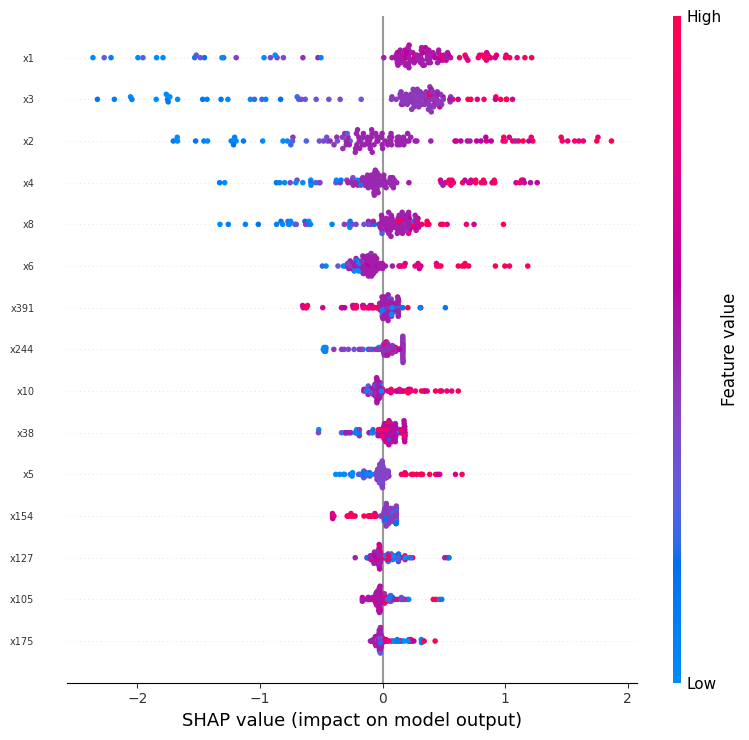

In [224]:
shap_values = model.predict(
    dtest,
    pred_contribs=True
)
plt.figure(figsize=(12, 16))
shap.summary_plot(
    shap_values[:, :-1],
    X_test,
    max_display=15,
    show=False
)

plt.yticks(fontsize=7)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

## 1000 round

In [225]:
boot_results = boot_multi_repeat_inference_keep_feature(
    X=X,
    y=y,
    task="binary",
    inner_variance="permutation",
    n_bootstrap=1000,
    b_model=1,
    zero_tol=1e-12,
    params=params,
    num_boost_round=150,
    n_jobs=6,
    xgb_nthread=1,
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 1000/1000 [03:49<00:00,  4.35it/s]


In [226]:
feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=boot_results,
    agg_col="sum_abs_shap",
    kernel="gaussian",
    bandwidth=0.1,
)

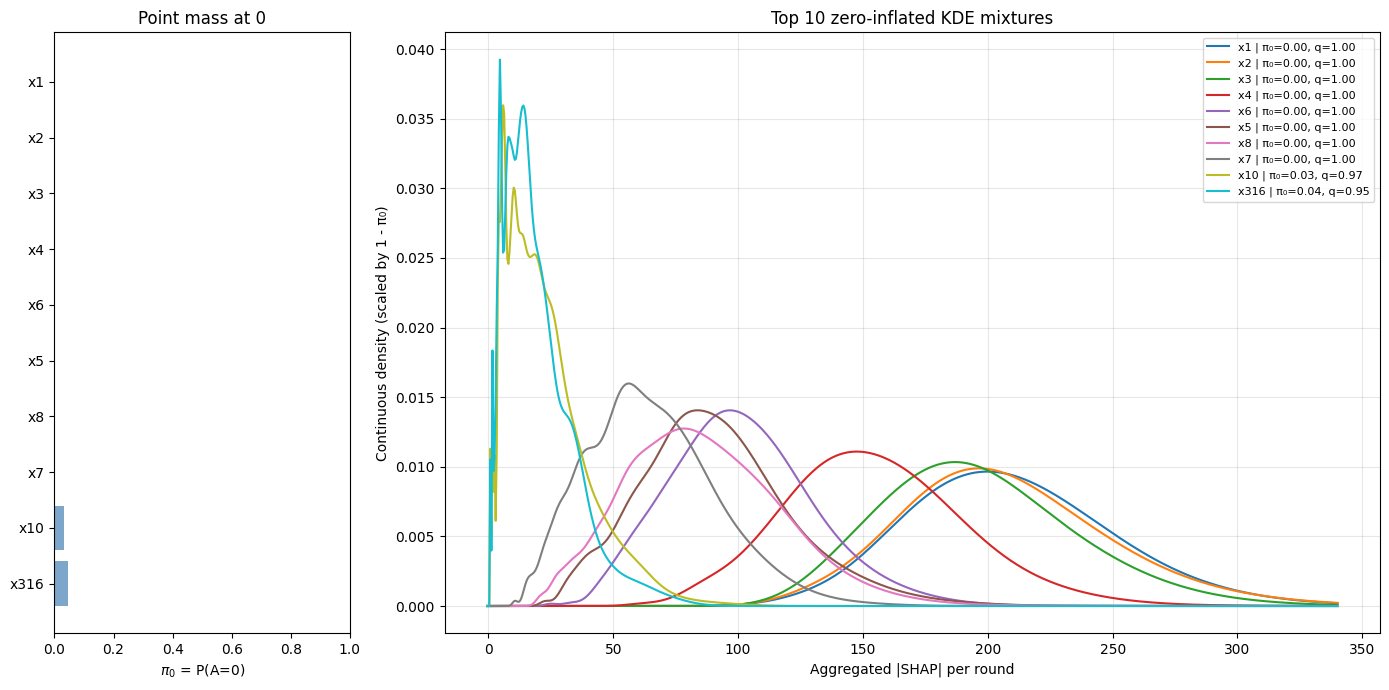

In [245]:
lgb_top = plot_top_feature_density(
    feature_kde,
    top_k=10,
    score_col="median",
    x_min = -0.5,
    log_x=False,
)

In [246]:
tmp = feature_kde.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["sd_estimated"]
tmp["stat"] = tmp["p_nonzero"]* tmp["median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
    "feature": "ID",
    "stat": "Robust",
    "nonzero_median": "Median",
    "sd_estimated": "Std",
}).round(3)

,ID,Robust,SNR,Median,Std,0PM(%)
Rank,,,,,,
1,x1,970.786,4.693,206.874,44.085,0.0%
2,x2,947.742,4.648,203.918,43.875,0.0%
3,x3,901.080,4.663,193.233,41.438,0.0%
4,x4,636.097,4.156,153.068,36.834,0.0%
5,x6,338.751,3.395,99.792,29.397,0.0%
6,x5,263.116,2.939,89.515,30.454,0.0%
7,x8,224.444,2.675,83.915,31.374,0.0%
8,x7,159.008,2.482,64.059,25.807,0.0%
9,x10,22.521,1.177,20.253,16.807,3.3%


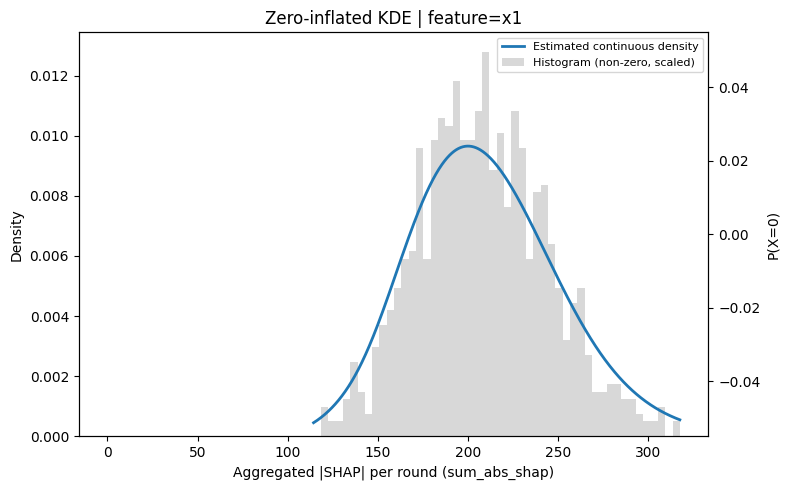

In [230]:
plot_feature_level_kde_with_hist_preagg(
    feature_level_df=feature_kde,
    boot_results=boot_results,
    feature="x1",
    bins = 50
)

In [231]:
from scipy.stats import shapiro

boot_df = pd.concat(boot_results, ignore_index=True)
x1_vals = boot_df.loc[boot_df["feature"] == "x1", "sum_abs_shap"].values

n = min(len(x1_vals), 5000)
stat, p = shapiro(x1_vals[:n])
print(f"Shapiro-Wilk normality test on x1 sum_abs_shap (n={n}):")
print(f"  W = {stat:.4f},  p = {p:.4e}")

Shapiro-Wilk normality test on x1 sum_abs_shap (n=1000):
  W = 0.9964,  p = 2.2812e-02


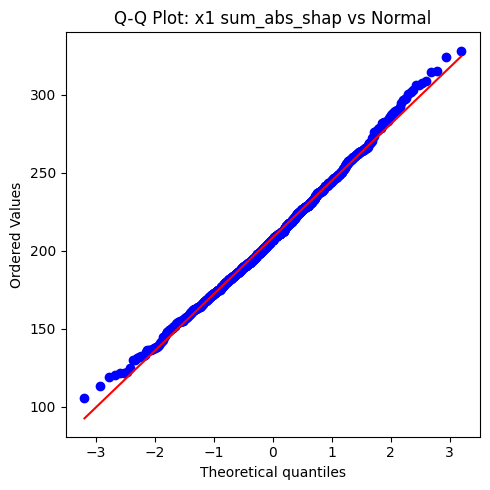

In [232]:
import scipy.stats as stats

fig, ax = plt.subplots(figsize=(5, 5))
stats.probplot(x1_vals, dist="norm", plot=ax)
ax.set_title("Q-Q Plot: x1 sum_abs_shap vs Normal")
plt.tight_layout()
plt.show()

## 10 round

In [233]:
boot_results_tiny = boot_multi_repeat_inference_keep_feature(
    X=X,
    y=y,
    task="binary",
    inner_variance="permutation",
    n_bootstrap=10,
    b_model=1,
    zero_tol=1e-12,
    params=params,
    num_boost_round=150,
    n_jobs=6,
    xgb_nthread=1,
    show_progress=True
)

Bootstrap repeats (feature-agg): 100%|██████████| 10/10 [00:03<00:00,  3.32it/s]


In [234]:
feature_kde_tiny = estimate_feature_level_mixture_preagg(
    boot_results=boot_results_tiny,
    agg_col="sum_abs_shap",
    kernel="gaussian",
    bandwidth=0.2,
)

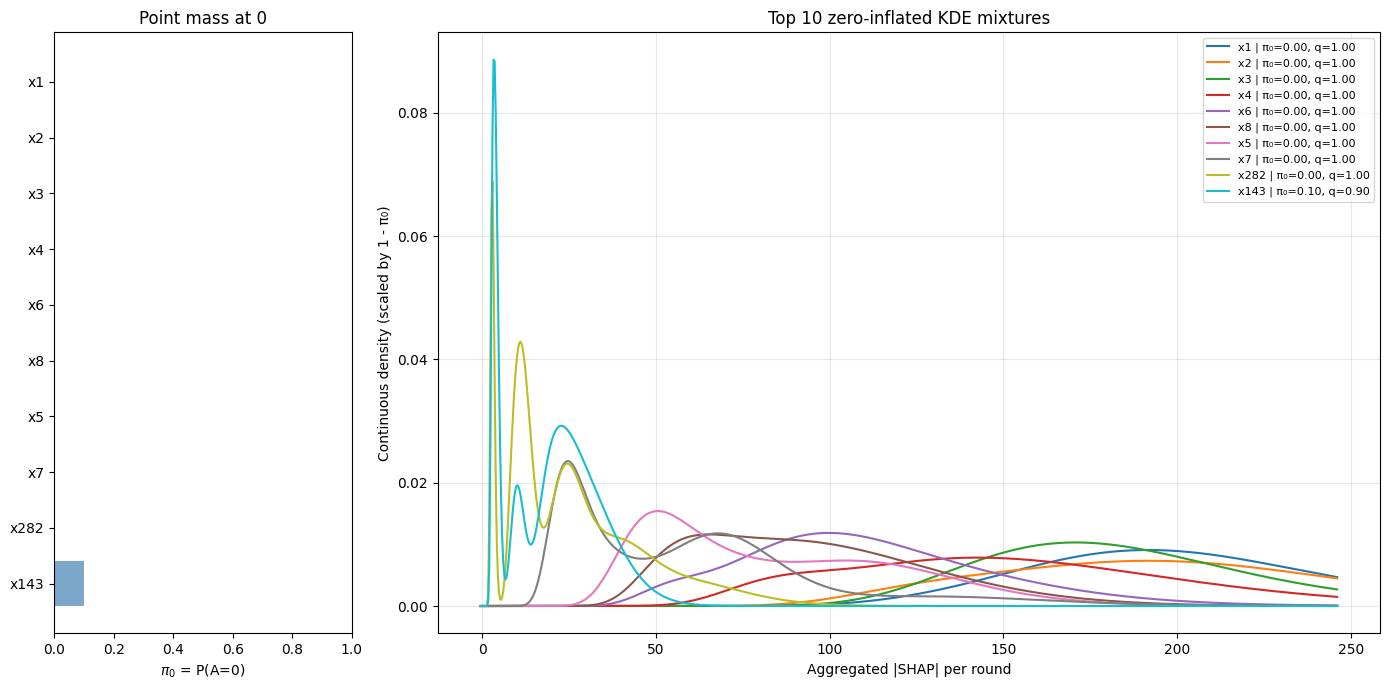

In [235]:
lgb_top = plot_top_feature_density(
    feature_kde_tiny,
    top_k=10,
    score_col="median",
    x_min = -0.5,
    log_x=False,
)

In [237]:
tmp = feature_kde_tiny.copy()

tmp["0PM(%)"] = (tmp["pi_zero"] * 100).round(1).astype(str) + "%"
tmp["SNR"] = tmp["median"] / tmp["std"]
tmp["stat"] = tmp["p_nonzero"]* tmp["median"] * tmp["SNR"]
                                
top = tmp.nlargest(15, "stat").reset_index(drop=True)
top.index += 1
top.index.name = "Rank"
top[["feature", "stat", "SNR", "nonzero_median", "sd_estimated", "0PM(%)"]].rename(columns={
    "feature": "ID",
    "stat": "Robust",
    "nonzero_median": "Median",
    "sd_estimated": "Std",
}).round(3)

,ID,Robust,SNR,Median,Std,0PM(%)
Rank,,,,,,
1,x1,1938.169,9.542,203.126,82.643,0.0%
2,x3,1704.493,9.773,174.405,73.971,0.0%
3,x2,1099.757,5.457,201.518,78.444,0.0%
4,x4,550.470,3.687,149.298,58.559,0.0%
5,x6,407.030,3.754,108.431,42.218,0.0%
6,x8,308.104,3.293,93.564,36.633,0.0%
7,x5,182.232,2.384,76.435,35.567,0.0%
8,x7,102.877,1.705,60.339,30.503,0.0%
9,x120,34.087,2.118,16.098,7.640,0.0%


## Prediction

In [259]:
sum_abs_shap = np.abs(shap_values[:,:-1]).sum(axis=0)
shap_top15 = (
    pd.Series(sum_abs_shap, index=X.columns)
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

In [260]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X[shap_top15], y, test_size=0.2, random_state=42, stratify=y)

# Prepare data for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest  = xgb.DMatrix(X_test,  label=y_test,  enable_categorical=True)
# Cross-validation on training data to find optimal parameters


num_rounds = 150 # number of iterations

In [261]:
# Perform 5-fold cross-validation on training data
print("Running 5-fold cross-validation on training data...")
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=num_rounds,
    nfold=5,  # 5-fold cross-validation
    metrics='logloss',  # binary logloss
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\n" + "="*50)
print("Cross-validation results:")
print(f"Best iteration: {len(cv_results)}")
print(f"Best CV logloss: {cv_results['test-logloss-mean'].min():.4f} (+/- {cv_results['test-logloss-std'].iloc[-1]:.4f})")
print("="*50)

# Train final model on all training data with optimal number of rounds
best_num_rounds = len(cv_results)
print(f"\nTraining final model with {best_num_rounds} rounds...")
model = xgb.train(params, dtrain, num_boost_round=best_num_rounds)

# Evaluate on held-out test set
# For binary:logistic, predict() returns probabilities, convert to class labels
y_pred_proba = model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)  # Convert probabilities to 0/1

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest set accuracy: {test_accuracy:.4f}")

# Show confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["0", "1"]))

Running 5-fold cross-validation on training data...
[0]	train-logloss:0.50170+0.00723	test-logloss:0.57431+0.03330
[1]	train-logloss:0.40038+0.00866	test-logloss:0.52839+0.03734
[2]	train-logloss:0.32309+0.00580	test-logloss:0.49355+0.04603
[3]	train-logloss:0.27471+0.00818	test-logloss:0.46995+0.04525
[4]	train-logloss:0.23635+0.00484	test-logloss:0.46100+0.04417
[5]	train-logloss:0.20414+0.00733	test-logloss:0.45111+0.04953
[6]	train-logloss:0.18050+0.00800	test-logloss:0.45641+0.04818
[7]	train-logloss:0.16403+0.00721	test-logloss:0.46470+0.05455
[8]	train-logloss:0.15011+0.00669	test-logloss:0.46004+0.05750
[9]	train-logloss:0.13938+0.00692	test-logloss:0.46211+0.06029
[10]	train-logloss:0.12874+0.00630	test-logloss:0.46655+0.06686
[11]	train-logloss:0.12017+0.00526	test-logloss:0.47151+0.07545
[12]	train-logloss:0.11135+0.00465	test-logloss:0.47561+0.07706
[13]	train-logloss:0.10459+0.00454	test-logloss:0.47258+0.07601
[14]	train-logloss:0.09845+0.00413	test-logloss:0.47326+0.0742

In [262]:
top15 = top['feature'].head(5).tolist()

In [263]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X[top15], y, test_size=0.2, random_state=42, stratify=y)

# Prepare data for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dtest  = xgb.DMatrix(X_test,  label=y_test,  enable_categorical=True)
# Cross-validation on training data to find optimal parameters


num_rounds = 150 # number of iterations

In [264]:
# Perform 5-fold cross-validation on training data
print("Running 5-fold cross-validation on training data...")
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=num_rounds,
    nfold=5,  # 5-fold cross-validation
    metrics='logloss',  # binary logloss
    early_stopping_rounds=10,
    verbose_eval=True
)

print("\n" + "="*50)
print("Cross-validation results:")
print(f"Best iteration: {len(cv_results)}")
print(f"Best CV logloss: {cv_results['test-logloss-mean'].min():.4f} (+/- {cv_results['test-logloss-std'].iloc[-1]:.4f})")
print("="*50)

# Train final model on all training data with optimal number of rounds
best_num_rounds = len(cv_results)
print(f"\nTraining final model with {best_num_rounds} rounds...")
model = xgb.train(params, dtrain, num_boost_round=best_num_rounds)

# Evaluate on held-out test set
# For binary:logistic, predict() returns probabilities, convert to class labels
y_pred_proba = model.predict(dtest)
y_pred = (y_pred_proba > 0.5).astype(int)  # Convert probabilities to 0/1

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest set accuracy: {test_accuracy:.4f}")

# Show confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["0", "1"]))

Running 5-fold cross-validation on training data...
[0]	train-logloss:0.51200+0.00915	test-logloss:0.59668+0.01866
[1]	train-logloss:0.40967+0.01243	test-logloss:0.54556+0.02403
[2]	train-logloss:0.32590+0.01275	test-logloss:0.49627+0.03294
[3]	train-logloss:0.27918+0.00915	test-logloss:0.49389+0.03241
[4]	train-logloss:0.24151+0.01042	test-logloss:0.48123+0.03976
[5]	train-logloss:0.20811+0.00950	test-logloss:0.47446+0.04604
[6]	train-logloss:0.18610+0.00910	test-logloss:0.47437+0.05258
[7]	train-logloss:0.16946+0.00826	test-logloss:0.47490+0.05557
[8]	train-logloss:0.15630+0.00751	test-logloss:0.47629+0.06153
[9]	train-logloss:0.14578+0.00729	test-logloss:0.47240+0.05525
[10]	train-logloss:0.13700+0.00726	test-logloss:0.47729+0.05387
[11]	train-logloss:0.12848+0.00772	test-logloss:0.48116+0.05717
[12]	train-logloss:0.11962+0.00639	test-logloss:0.48901+0.05501
[13]	train-logloss:0.11098+0.00560	test-logloss:0.49126+0.05337
[14]	train-logloss:0.10541+0.00624	test-logloss:0.49612+0.0600